# F1 Data Exploration
Explore FastF1 lap data, tire degradation patterns, and weather conditions.

In [1]:
from f1deg.viz.theme import apply_theme

apply_theme()

In [2]:
import fastf1
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
pd.set_option("display.max_columns", None)

In [4]:
fastf1.Cache.enable_cache("../data/cache")
session = fastf1.get_session(2023, 1, "R")
session.load(laps=True, weather=True, telemetry=False)
laps = session.laps
print(f"Loaded {len(laps)} laps from {session.event['EventName']}")
laps.head()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


Loaded 1056 laps from Bahrain Grand Prix


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:04:15.902000,VER,1,0 days 00:01:39.019000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.414000,0 days 00:00:23.842000,NaT,0 days 01:03:52.119000,0 days 01:04:16.010000,232.0,231.0,278.0,252.0,False,SOFT,4.0,False,Red Bull Racing,0 days 01:02:36.652000,NaT,12,1.0,False,,False,False
1,0 days 01:05:53.876000,VER,1,0 days 00:01:37.974000,2.0,1.0,NaT,NaT,0 days 00:00:31.342000,0 days 00:00:42.504000,0 days 00:00:24.128000,0 days 01:04:47.303000,0 days 01:05:29.807000,0 days 01:05:53.935000,227.0,238.0,278.0,288.0,True,SOFT,5.0,False,Red Bull Racing,0 days 01:04:15.902000,NaT,12,1.0,False,,False,True
2,0 days 01:07:31.882000,VER,1,0 days 00:01:38.006000,3.0,1.0,NaT,NaT,0 days 00:00:31.388000,0 days 00:00:42.469000,0 days 00:00:24.149000,0 days 01:06:25.323000,0 days 01:07:07.792000,0 days 01:07:31.941000,227.0,238.0,278.0,287.0,False,SOFT,6.0,False,Red Bull Racing,0 days 01:05:53.876000,NaT,1,1.0,False,,False,True
3,0 days 01:09:09.858000,VER,1,0 days 00:01:37.976000,4.0,1.0,NaT,NaT,0 days 00:00:31.271000,0 days 00:00:42.642000,0 days 00:00:24.063000,0 days 01:08:03.212000,0 days 01:08:45.854000,0 days 01:09:09.917000,228.0,238.0,278.0,289.0,False,SOFT,7.0,False,Red Bull Racing,0 days 01:07:31.882000,NaT,1,1.0,False,,False,True
4,0 days 01:10:47.893000,VER,1,0 days 00:01:38.035000,5.0,1.0,NaT,NaT,0 days 00:00:31.244000,0 days 00:00:42.724000,0 days 00:00:24.067000,0 days 01:09:41.161000,0 days 01:10:23.885000,0 days 01:10:47.952000,228.0,239.0,278.0,290.0,False,SOFT,8.0,False,Red Bull Racing,0 days 01:09:09.858000,NaT,1,1.0,False,,False,True


## Lap Times by Compound

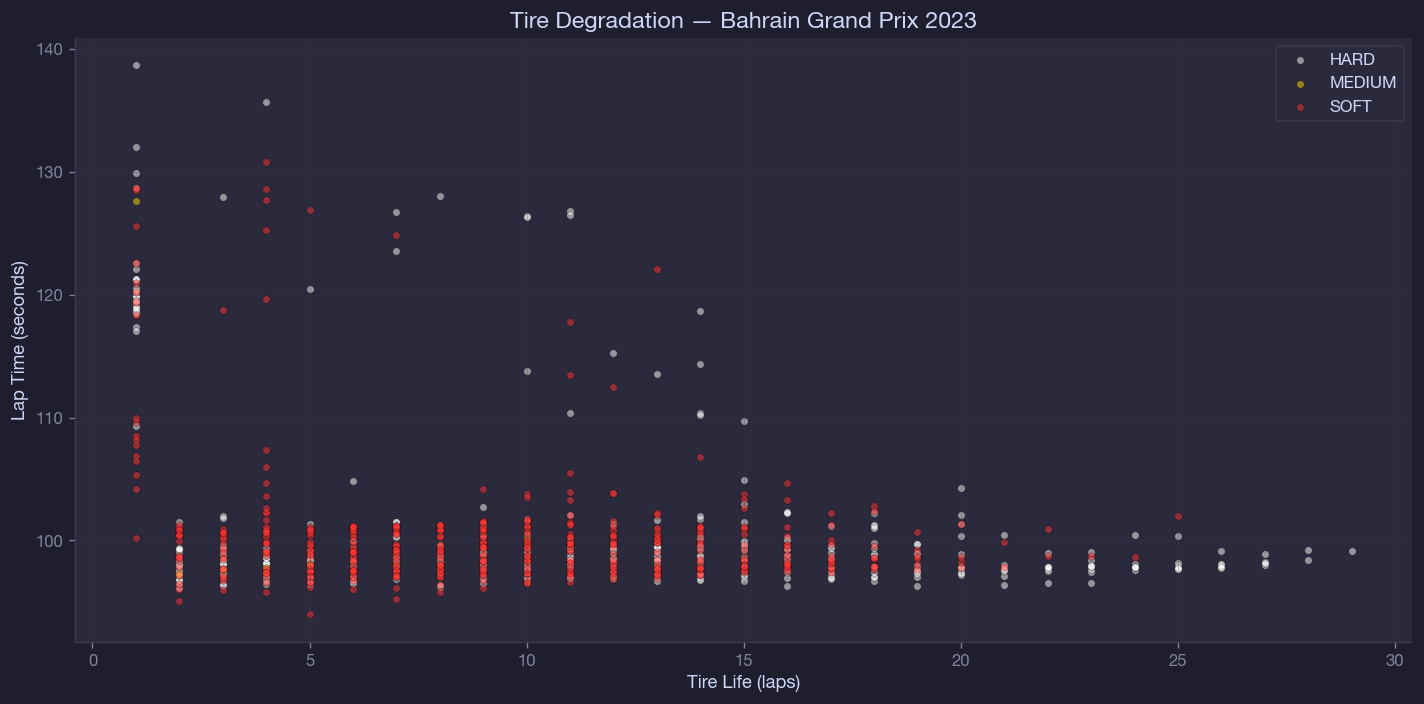

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
for compound, group in laps.groupby("Compound"):
    color = {"SOFT": "#FF3333", "MEDIUM": "#FFD700", "HARD": "#FFFFFF"}.get(compound, "#999")
    ax.scatter(
        group["TyreLife"],
        group["LapTime"].dt.total_seconds(),
        c=color,
        edgecolors="black",
        linewidths=0.3,
        alpha=0.5,
        s=20,
        label=compound,
    )
ax.set_xlabel("Tire Life (laps)")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title(f"Tire Degradation — {session.event['EventName']} {session.event.year}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Tire Life Distribution

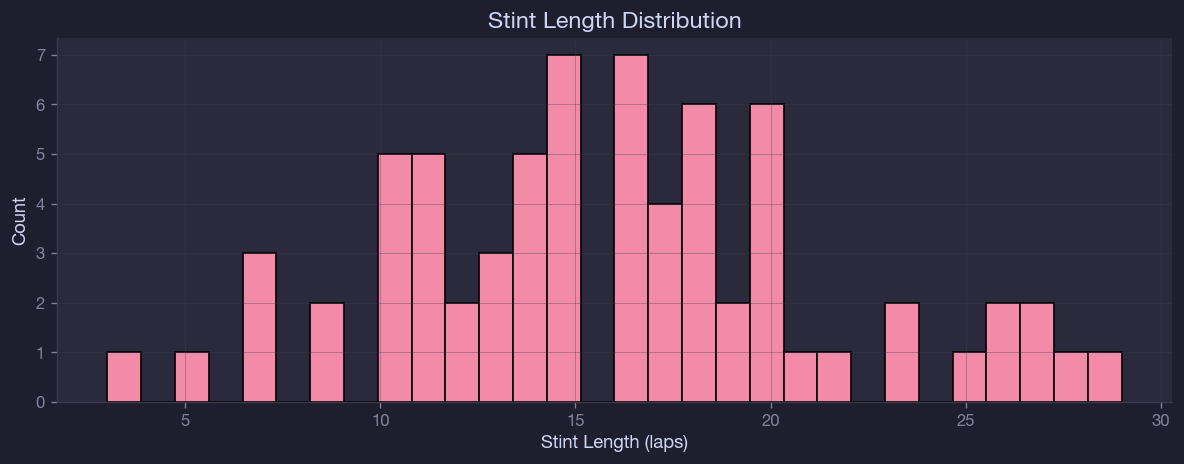

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
laps.groupby(["Driver", "Stint"])["TyreLife"].max().hist(bins=30, ax=ax, edgecolor="black")
ax.set_xlabel("Stint Length (laps)")
ax.set_ylabel("Count")
ax.set_title("Stint Length Distribution")
plt.tight_layout()
plt.show()

## Weather Data

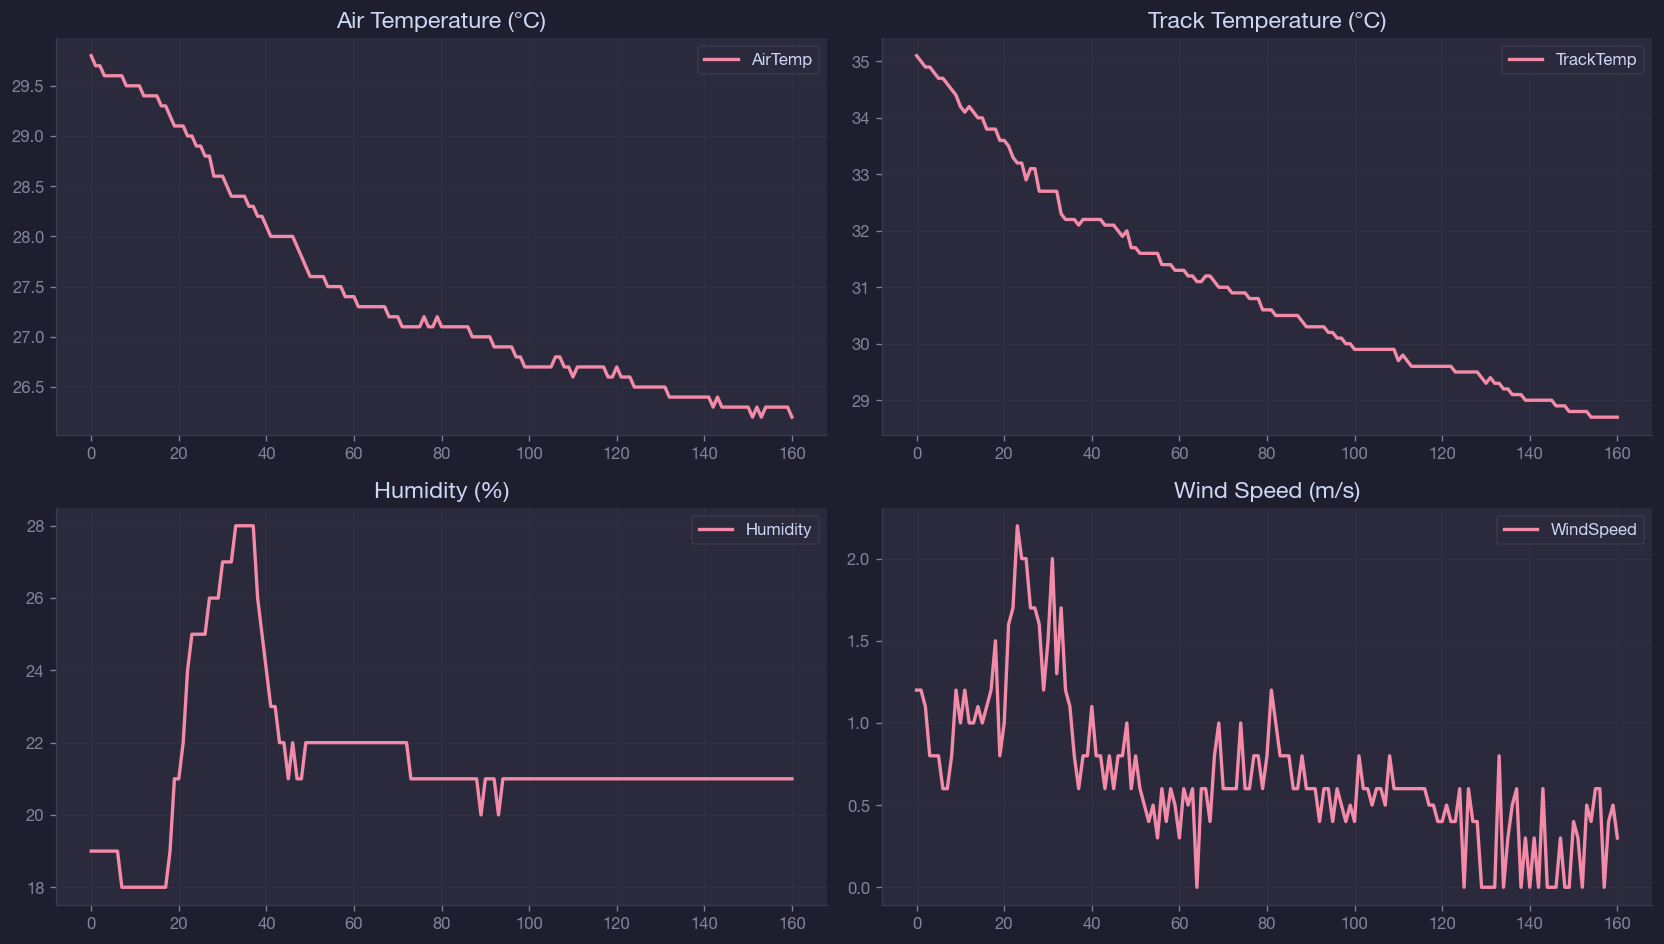

In [7]:
weather = session.weather_data
if weather is not None and not weather.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    weather.plot(y="AirTemp", ax=axes[0, 0], title="Air Temperature (°C)")
    weather.plot(y="TrackTemp", ax=axes[0, 1], title="Track Temperature (°C)")
    weather.plot(y="Humidity", ax=axes[1, 0], title="Humidity (%)")
    weather.plot(y="WindSpeed", ax=axes[1, 1], title="Wind Speed (m/s)")
    plt.tight_layout()
    plt.show()
else:
    print("No weather data available for this session")